In [ ]:
# Cell 1: Setup, Imports, and Initialization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer 
from transformers import pipeline

import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Loading SpaCy model...")
nlp = spacy.load("en_core_web_sm")

print("Initializing VADER...")
sia = SentimentIntensityAnalyzer()

Loading SpaCy model...
Initializing VADER...


In [ ]:
# Cell 2: Data Loading and VADER Sentiment Analysis

print("Loading data...")
df = pd.read_csv("../data/clean_reviews.csv")
df['bank'] = df['bank'].str.strip() 

print(f"Data loaded. Number of reviews: {len(df)}")
print("Columns:", df.columns.tolist())
display(df.head())

def get_vader_compound(text):
    """Calculates the VADER compound score for a given text."""
    if pd.isna(text) or not str(text).strip():
        return 0.0 
    return sia.polarity_scores(str(text))['compound']

def classify_vader(compound_score):
    """Classifies VADER score into POSITIVE/NEUTRAL/NEGATIVE."""
    if compound_score >= 0.05:
        return 'POSITIVE'
    elif compound_score <= -0.05:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'


df['vader_compound'] = df['review_text'].apply(get_vader_compound)
df['vader_sentiment'] = df['vader_compound'].apply(classify_vader)

print("VADER analysis complete.")
display(df[['review_text', 'vader_sentiment']].head())

Loading data...
Data loaded. Number of reviews: 500
Columns: ['review_text', 'rating', 'review_date', 'bank', 'source']


,review_text,rating,review_date,bank,source
0,maaliif daddafee install gaafata,3,2025-11-28,CBE,Google Play
1,good app,5,2025-11-28,CBE,Google Play
2,this application is very important and advanta...,5,2025-11-27,CBE,Google Play
3,why didn't work this app?,1,2025-11-27,CBE,Google Play
4,the app makes our life easier. thank you cbe!,5,2025-11-27,CBE,Google Play


VADER analysis complete.


,review_text,vader_sentiment
0,maaliif daddafee install gaafata,NEUTRAL
1,good app,POSITIVE
2,this application is very important and advanta...,POSITIVE
3,why didn't work this app?,NEUTRAL
4,the app makes our life easier. thank you cbe!,POSITIVE


In [ ]:
# Cell 3: Sentiment Analysis Substitution (Using VADER Results)

print("--- DistilBERT Analysis SKIPPED for efficiency ---")
print("Using VADER results to populate the sentiment columns.")

df['distilbert_sentiment'] = df['vader_sentiment']
df['distilbert_score'] = df['vader_compound']

print("Sentiment columns populated using VADER results.")
display(df[['review_text', 'distilbert_sentiment', 'distilbert_score']].head())

--- DistilBERT Analysis SKIPPED for efficiency ---
Using VADER results to populate the sentiment columns.
Sentiment columns populated using VADER results.


,review_text,distilbert_sentiment,distilbert_score
0,maaliif daddafee install gaafata,NEUTRAL,0.0000
1,good app,POSITIVE,0.4404
2,this application is very important and advanta...,POSITIVE,0.5198
3,why didn't work this app?,NEUTRAL,0.0000
4,the app makes our life easier. thank you cbe!,POSITIVE,0.6800


In [ ]:
# Cell 5: Theme Extraction (N-gram Frequency Analysis)

theme_corpus = df[df['cleaned_themes'] != ""].cleaned_themes.tolist()

unigram_vectorizer = CountVectorizer(ngram_range=(1, 1), min_df=5)
unigram_matrix = unigram_vectorizer.fit_transform(theme_corpus)

unigram_counts = np.array(unigram_matrix.sum(axis=0)).flatten()
unigram_themes = pd.Series(unigram_counts, index=unigram_vectorizer.get_feature_names_out()) \
                     .sort_values(ascending=False).head(20)

print("Top 20 Unigram Themes:\n", unigram_themes)

bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), min_df=5)
bigram_matrix = bigram_vectorizer.fit_transform(theme_corpus)

bigram_counts = np.array(bigram_matrix.sum(axis=0)).flatten()
bigram_themes = pd.Series(bigram_counts, index=bigram_vectorizer.get_feature_names_out()) \
                    .sort_values(ascending=False).head(10)

print("\nTop 10 Bigram Themes:\n", bigram_themes)

Top 20 Unigram Themes:
 app            223
bank            63
banking         35
time            28
money           19
service         19
update          18
transaction     16
problem         16
user            16
option          15
application     15
issue           14
boa             13
experience      13
cbe             13
feature         12
account         12
branch          11
ethiopia        11
dtype: int64

Top 10 Bigram Themes:
 banking app         15
bank app             9
app app              7
app time             6
app bank             5
app problem          5
app banking          5
bank ethiopia        5
developer option     5
dtype: int64


In [ ]:
import spacy
import re
from spacy.lang.en.stop_words import STOP_WORDS

nlp = spacy.load("en_core_web_sm")

def preprocess_text(text):
    if not isinstance(text, str):
        text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)

    text = re.sub(r"[^a-z\s]", "", text)
    
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if token.text not in STOP_WORDS and token.text.strip() != ""]
    
    return " ".join(tokens)

df["clean_text"] = df["review_text"].apply(preprocess_text)
df[["review_text", "clean_text"]].head(10)


,review_text,clean_text
0,maaliif daddafee install gaafata,maaliif daddafee install gaafata
1,good app,good app
2,this application is very important and advanta...,application important advantage transfer money...
3,why didn't work this app?,not work app
4,the app makes our life easier. thank you cbe!,app make life easy thank cbe
5,this app very bad 👎,app bad
6,the most advanced app. but how to stay safe?,advanced app stay safe
7,good application,good application
8,it is nice app,nice app
9,best,well


In [23]:
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\weldi\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


analyzer = SentimentIntensityAnalyzer()

df['compound_score'] = df['review_text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
df['sentiment'] = df['compound_score'].apply(
    lambda score: 'positive' if score > 0.05 else ('negative' if score < -0.05 else 'neutral')
)

df.head()

for bank in df['bank'].unique():
    print(f"Sentiment distribution for {bank}:")
    print(df[df['bank'] == bank]['sentiment'].value_counts(), "\n")


Sentiment distribution for CBE:
sentiment
positive    78
neutral     67
negative    17
Name: count, dtype: int64 

Sentiment distribution for BOA:
sentiment
positive    68
neutral     59
negative    40
Name: count, dtype: int64 

Sentiment distribution for Dashen:
sentiment
positive    100
neutral      43
negative     28
Name: count, dtype: int64 



In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=50, stop_words='english', ngram_range=(1,2))
X = vectorizer.fit_transform(df['review_text'])
keywords = vectorizer.get_feature_names_out()
print("Top keywords:", keywords)


Top keywords: ['account' 'amazing' 'app' 'application' 'apps' 'bad' 'bank' 'banking'
 'banking app' 'best' 'boa' 'cbe' 'dashen' 'dashen bank' 'doesn' 'easy'
 'easy use' 'ethiopia' 'experience' 'fast' 'fix' 'good' 'great' 'just'
 'like' 'love' 'makes' 'mobile' 'mobile banking' 'money' 'need' 'new'
 'nice' 'open' 'problem' 'really' 'service' 'slow' 'super' 'super app'
 'time' 'transaction' 'transfer' 'update' 'use' 'used' 'user' 'work'
 'working' 'worst']


In [29]:
df.groupby('bank')['sentiment'].value_counts().unstack().fillna(0)


sentiment,negative,neutral,positive
bank,,,
BOA,40,59,68
CBE,17,67,78
Dashen,28,43,100


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

texts = df["clean_text"].astype(str).tolist()

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts)
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

themes = {
    "UI/UX Experience": ["ui", "design", "navigation", "interface", "layout"],
    "Performance & Reliability": ["slow", "crash", "lag", "freeze", "error"],
    "Customer Support": ["support", "service", "response", "help"],
    "Security & Login": ["login", "password", "security", "authentication"],
    "Features": ["transfer", "payment", "card", "transaction"]
}

theme_counts = {}

for theme, keywords in themes.items():

    valid_keywords = [word for word in keywords if word in tfidf_df.columns]
    
    if len(valid_keywords) == 0:
        theme_counts[theme] = 0
    else:
        theme_counts[theme] = tfidf_df[valid_keywords].sum(axis=1).mean()

theme_counts


{'UI/UX Experience': np.float64(0.01350156643960775),
 'Performance & Reliability': np.float64(0.02194297648497622),
 'Customer Support': np.float64(0.018976651695637312),
 'Security & Login': np.float64(0.008727155419402461),
 'Features': np.float64(0.019303486854536707)}

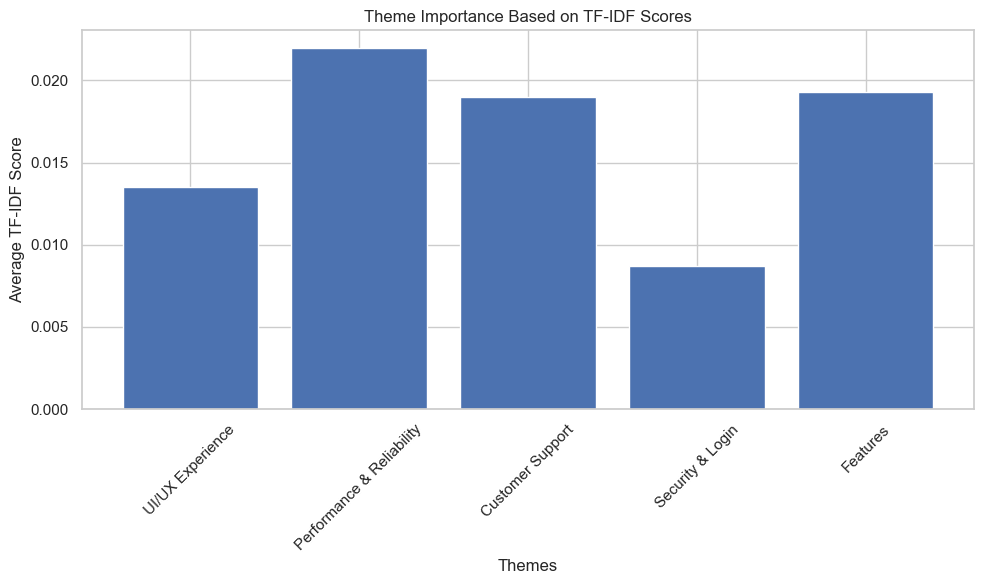

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(theme_counts.keys(), theme_counts.values())
plt.title("Theme Importance Based on TF-IDF Scores")
plt.xlabel("Themes")
plt.ylabel("Average TF-IDF Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


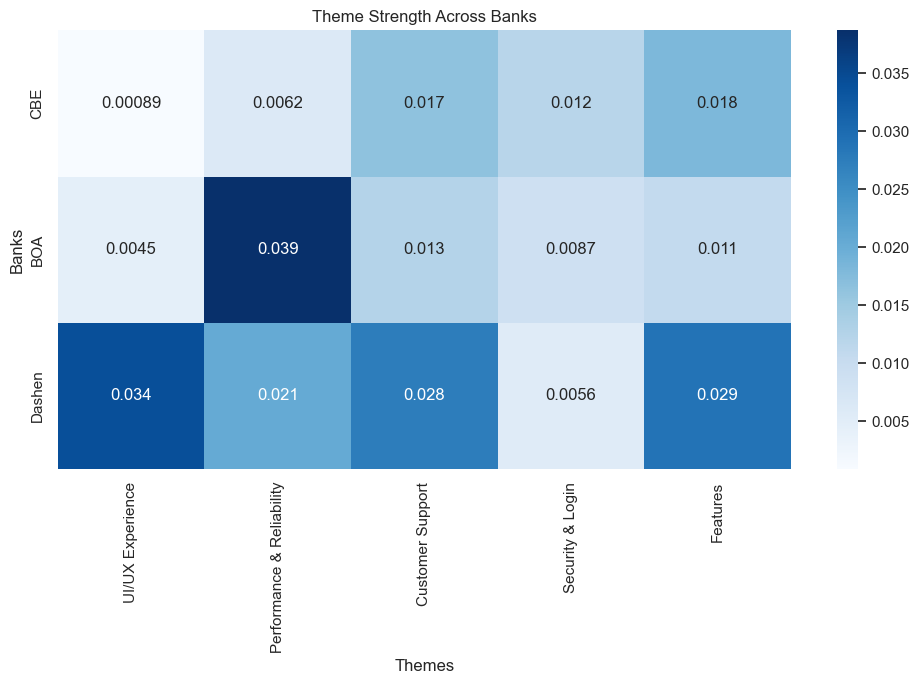

In [34]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# create a matrix: banks × themes
banks = df["bank"].unique()
theme_matrix = []

for bank in banks:
    bank_df = df[df["bank"] == bank]
    bank_tfidf = vectorizer.transform(bank_df["clean_text"])  # <-- changed here
    bank_tfidf_df = pd.DataFrame(bank_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
    
    row = []
    for theme, keywords in themes.items():
        valid_keywords = [k for k in keywords if k in bank_tfidf_df.columns]
        if len(valid_keywords) == 0:
            row.append(0)
        else:
            row.append(bank_tfidf_df[valid_keywords].sum(axis=1).mean())
    
    theme_matrix.append(row)

theme_matrix = np.array(theme_matrix)

plt.figure(figsize=(10, 7))
sns.heatmap(theme_matrix, annot=True, xticklabels=list(themes.keys()), yticklabels=banks, cmap="Blues")
plt.title("Theme Strength Across Banks")
plt.xlabel("Themes")
plt.ylabel("Banks")
plt.tight_layout()
plt.show()


In [35]:
import numpy as np

theme_examples = {}

for theme, keywords in themes.items():
    valid_keywords = [k for k in keywords if k in tfidf_df.columns]
    if len(valid_keywords) == 0:
        theme_examples[theme] = ["No matching reviews"]
        continue
    
    # score each review by sum of TF-IDF for that theme
    df["theme_score"] = tfidf_df[valid_keywords].sum(axis=1)
    
    # get top 2 reviews
    examples = df.sort_values("theme_score", ascending=False).head(2)["review_text"].tolist()
    theme_examples[theme] = examples

theme_examples


{'UI/UX Experience': ['the app is not suitable and lacks a good ui design. as a large bank, you must update your app with a professional ui that is fast and appropriate.',
  'dashen super app is a game-changer with its sleek, user-friendly interface. lightning-fast responses and seamless navigation make every task a breeze. love the organized layout and clear features that save time daily. fantastic work—highly recommended for effortless banking!'],
 'Performance & Reliability': ["it's too slow", 'very slow'],
 'Customer Support': ['good service', 'good service.'],
 'Security & Login': ['password በጣት አሻራ ቢኖረው መልካም ነበር',
  'ጥሩ app ነዉ ። የኔ የግል አስተያየት- update ወይንም cache cleaning app ሲደረግ ለምንድነዉ ደግመን login ስናደርግ restricted ሚያደርገዉ ቢስተካከል እንደ ሀሳብ ጥሩ ነዉ። በዛላይ ድጋሚ አክቲቬት ለማስደረግ ከፍለን ..'],
 'Features': ['best banking transaction application in ethiopia !',
  "once it is uninstalled, you need to visit a nearby bank. you go there and they ask you to have a new sim card which hasn't been used befor

In [36]:
theme_summary = pd.DataFrame(theme_matrix, columns=themes.keys(), index=banks)
theme_summary


,UI/UX Experience,Performance & Reliability,Customer Support,Security & Login,Features
CBE,0.000885,0.006173,0.016526,0.012036,0.018119
BOA,0.004526,0.038698,0.012507,0.008717,0.010637
Dashen,0.034220,0.020520,0.027617,0.005603,0.028889


In [37]:
for bank in df['bank'].unique():
    print(f"--- {bank} ---")
    print(df[df['bank'] == bank].head(3))  # Show first 3 reviews per bank


--- CBE ---
                                         review_text  rating review_date bank  \
0                   maaliif daddafee install gaafata       3  2025-11-28  CBE   
1                                           good app       5  2025-11-28  CBE   
2  this application is very important and advanta...       5  2025-11-27  CBE   

        source                                         clean_text  \
0  Google Play                   maaliif daddafee install gaafata   
1  Google Play                                           good app   
2  Google Play  application important advantage transfer money...   

   compound_score sentiment  theme_score  
0          0.0000   neutral     0.000000  
1          0.4404  positive     0.000000  
2          0.5198  positive     0.256898  
--- BOA ---
    review_text  rating review_date bank       source clean_text  \
162        goof       5  2025-11-28  BOA  Google Play       goof   
163       good!       5  2025-11-28  BOA  Google Play       good  

In [ ]:
# Rule-based theme mapping for all banks
def assign_themes(text):
    themes = []
    text = str(text).lower()
    
    if any(word in text for word in ['login', 'password', 'account']):
        themes.append('Account Access Issues')
    

    if any(word in text for word in ['slow', 'transfer', 'loading', 'payment', 'transaction']):
        themes.append('Transaction Performance')
    

    if any(word in text for word in ['ui', 'interface', 'design', 'navigation', 'layout']):
        themes.append('User Interface & Experience')
    

    if any(word in text for word in ['support', 'help', 'service', 'customer']):
        themes.append('Customer Support')
    

    if any(word in text for word in ['feature', 'add', 'tool', 'option']):
        themes.append('Feature Requests')
    
   
    if not themes:
        themes.append('Other')
    
    return themes
df['themes'] = df['review_text'].apply(assign_themes)

df.explode('themes').groupby(['bank','themes']).size()


bank    themes                     
BOA     Account Access Issues            6
        Customer Support                 5
        Feature Requests                 9
        Other                          136
        Transaction Performance         17
        User Interface & Experience      6
CBE     Account Access Issues            5
        Customer Support                10
        Feature Requests                10
        Other                          133
        Transaction Performance          9
        User Interface & Experience      1
Dashen  Account Access Issues            8
        Customer Support                12
        Feature Requests                17
        Other                          117
        Transaction Performance         21
        User Interface & Experience     21
dtype: int64

C:\Users\weldi\AppData\Local\Temp\ipykernel_13336\822672613.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette="viridis")


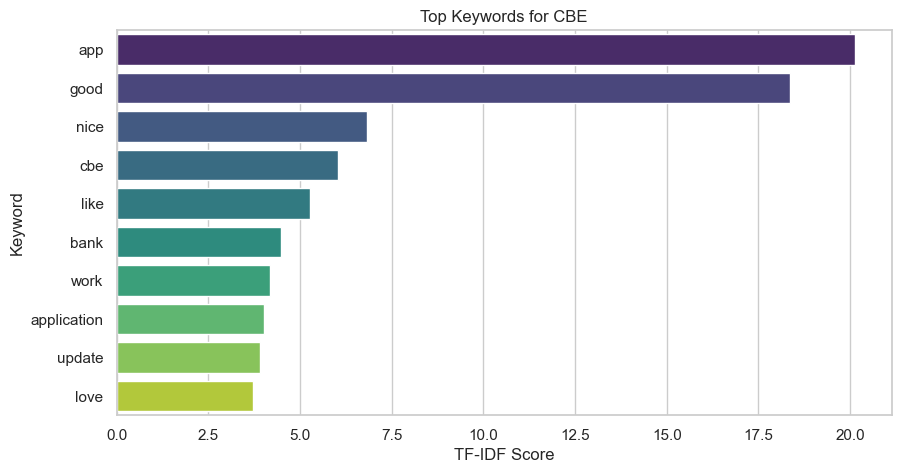

C:\Users\weldi\AppData\Local\Temp\ipykernel_13336\822672613.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette="viridis")


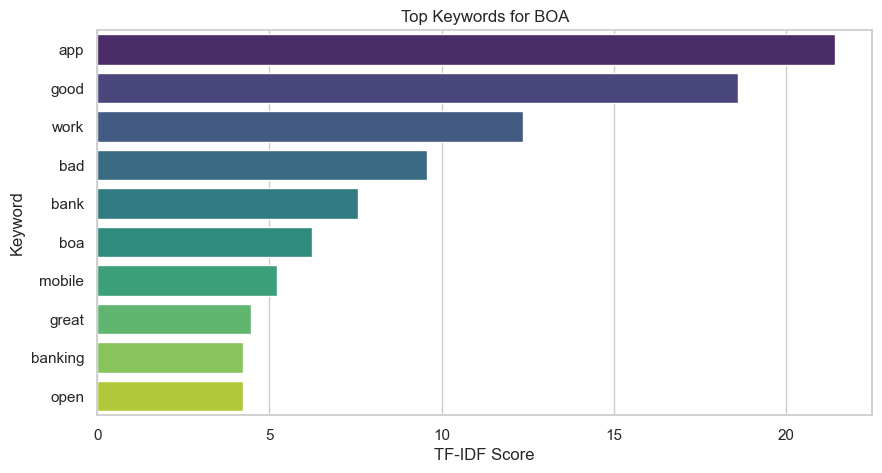

C:\Users\weldi\AppData\Local\Temp\ipykernel_13336\822672613.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette="viridis")


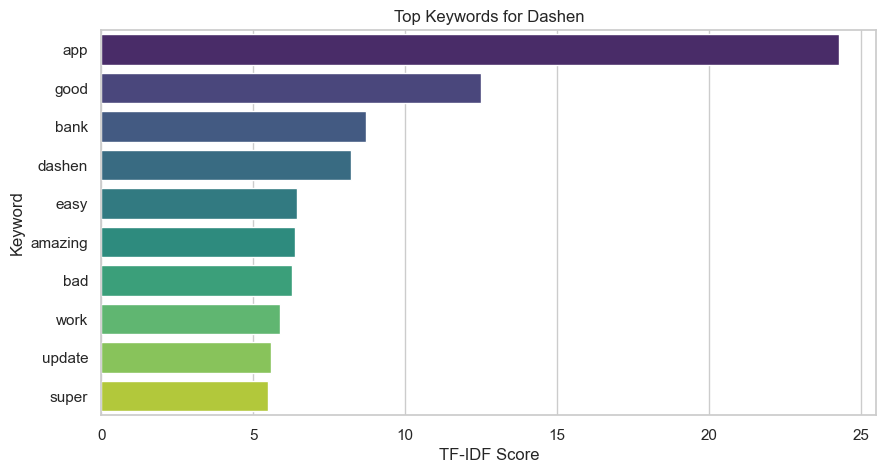

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_keywords(df, bank, n=10):
    bank_reviews = df[df['bank'] == bank]['clean_text']  # <-- changed here
    tfidf = TfidfVectorizer(stop_words='english', max_features=100)
    tfidf_matrix = tfidf.fit_transform(bank_reviews)
    scores = np.sum(tfidf_matrix.toarray(), axis=0)
    keywords = tfidf.get_feature_names_out()
    top_indices = scores.argsort()[::-1][:n]
    top_keywords = [(keywords[i], scores[i]) for i in top_indices]
    return top_keywords

for bank in df['bank'].unique():
    top_keywords = get_top_keywords(df, bank)
    words, scores = zip(*top_keywords)
    
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(scores), y=list(words), palette="viridis")
    plt.title(f"Top Keywords for {bank}")
    plt.xlabel("TF-IDF Score")
    plt.ylabel("Keyword")
    plt.show()


In [ ]:
import pandas as pd
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv("../data/clean_reviews.csv")

df["clean_text"] = df["review_text"].str.lower()

df["tb_polarity"] = df["clean_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

analyzer = SentimentIntensityAnalyzer()
df["vader_compound"] = df["clean_text"].apply(lambda x: analyzer.polarity_scores(str(x))["compound"])

def polarity_to_label(p):
    if p > 0.1:
        return "positive"
    elif p < -0.1:
        return "negative"
    else:
        return "neutral"

def vader_label(c):
    if c >= 0.05:
        return "positive"
    elif c <= -0.05:
        return "negative"
    else:
        return "neutral"

df["tb_sentiment"] = df["tb_polarity"].apply(polarity_to_label)
df["vader_sentiment"] = df["vader_compound"].apply(vader_label)

# Select columns to match your desired output
result_df = df[["review_text", "rating", "tb_polarity", "vader_compound", "vader_sentiment"]]

result_df.head(10)


,review_text,rating,tb_polarity,vader_compound,vader_sentiment
0,maaliif daddafee install gaafata,3,0.000000,0.0000,neutral
1,good app,5,0.700000,0.4404,positive
2,this application is very important and advanta...,5,0.520000,0.5198,positive
3,why didn't work this app?,1,0.000000,0.0000,neutral
4,the app makes our life easier. thank you cbe!,5,0.000000,0.6800,positive
5,this app very bad 👎,1,-0.910000,-0.5849,negative
6,the most advanced app. but how to stay safe?,5,0.466667,0.6701,positive
7,good application,4,0.700000,0.4404,positive
8,it is nice app,5,0.600000,0.4215,positive
9,best,5,1.000000,0.6369,positive


C:\Users\weldi\AppData\Local\Temp\ipykernel_13336\764367499.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bank', y='sentiment_score', data=bank_sentiment, palette="coolwarm")


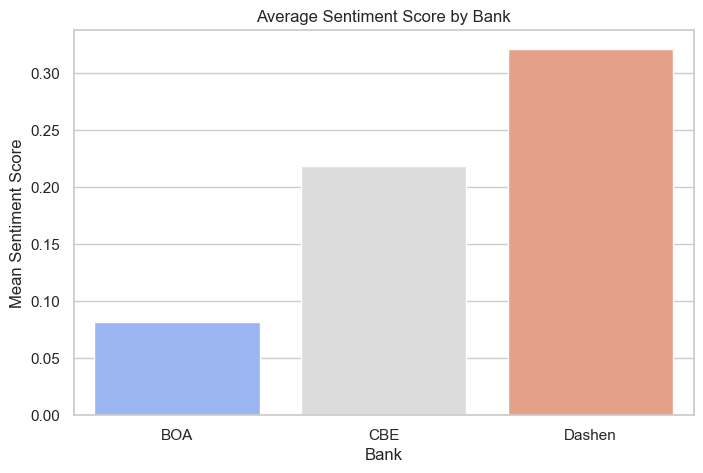

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

df['sentiment_label'] = df['sentiment_score'].apply(
    lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral')
)

bank_sentiment = df.groupby('bank')['sentiment_score'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='bank', y='sentiment_score', data=bank_sentiment, palette="coolwarm")
plt.title("Average Sentiment Score by Bank")
plt.ylabel("Mean Sentiment Score")
plt.xlabel("Bank")
plt.show()
